In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('../data/titanic.csv')

# Создаём копию для числовых расчётов (без преобразования в категории)
df_num = df.copy()

# Для удобства преобразуем типы в основном df (как в первом ноутбуке)
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Основные данные загружены, размер:", df.shape)
print("Числовая копия создана, размер:", df_num.shape)

Основные данные загружены, размер: (891, 12)
Числовая копия создана, размер: (891, 12)


## Задание 1. Типы признаков и шкалы измерения

### 1.1. Типы шкал для каждого признака

| Признак       | Тип шкалы       | Обоснование |
|---------------|------------------|-------------|
| PassengerId   | Номинальная      | Идентификатор, числа не имеют порядка |
| Survived      | Номинальная      | Категория «выжил/не выжил» без порядка |
| Pclass        | Порядковая       | 1,2,3 класс — есть порядок, но разница не равна |
| Name          | Номинальная      | Имена, нет порядка |
| Sex           | Номинальная      | Пол, две категории |
| Age           | Отношений        | Возраст, есть абсолютный ноль, можно делить |
| SibSp         | Абсолютная       | Количество, целое неотрицательное |
| Parch         | Абсолютная       | Аналогично |
| Ticket        | Номинальная      | Номер билета, просто метка |
| Fare          | Отношений        | Стоимость, есть ноль, можно делить |
| Cabin         | Номинальная      | Номер каюты, категория |
| Embarked      | Номинальная      | Порт посадки, категория |

In [3]:
# Используем числовую копию df_num для расчёта статистик

print("=== Pclass (порядковая шкала) ===")
print("Мода:", df_num['Pclass'].mode()[0])
print("Медиана:", df_num['Pclass'].median())
print("Среднее:", df_num['Pclass'].mean())
print()

print("=== Fare (шкала отношений) ===")
print("Мода:", df_num['Fare'].mode()[0])
print("Медиана:", df_num['Fare'].median())
print("Среднее:", df_num['Fare'].mean())

=== Pclass (порядковая шкала) ===
Мода: 3
Медиана: 3.0
Среднее: 2.308641975308642

=== Fare (шкала отношений) ===
Мода: 8.05
Медиана: 14.4542
Среднее: 32.204207968574636


### 1.2. Выводы по двум признакам

**Pclass (порядковая шкала)**  
- Среднее арифметическое: **некорректно**, потому что интервалы между классами не равны (1 класс не «в два раза лучше» 2-го).  
- Медиана: **корректна** – показывает «средний» класс.  
- Мода: **корректна** – наиболее частый класс (3-й класс).

**Fare (шкала отношений)**  
- Среднее арифметическое: **корректно** – можно суммировать и делить.  
- Медиана: **корректна** – устойчива к выбросам.  
- Мода: **корректна**, но для непрерывных величин может быть не очень информативна без группировки.

**Общий вывод:** Для порядковых шкал среднее арифметическое может вводить в заблуждение. Для шкалы отношений все три статистики допустимы.

In [4]:
# Создаём столбец-индикатор: True, если возраст пропущен, иначе False
df['age_missing'] = df['Age'].isna()

# Считаем долю пропусков
missing_rate = df['age_missing'].mean() * 100
print(f"Доля пропусков в Age: {missing_rate:.1f}%")
print(f"Количество пропусков: {df['age_missing'].sum()}")

Доля пропусков в Age: 19.9%
Количество пропусков: 177


## Задание 2. Диагностика типа пропусков

### 2.1. Индикатор пропуска в возрасте
- Доля пропусков в Age составила 19.9% (177 записей).
- Это значительная доля, поэтому важно понять природу пропусков.

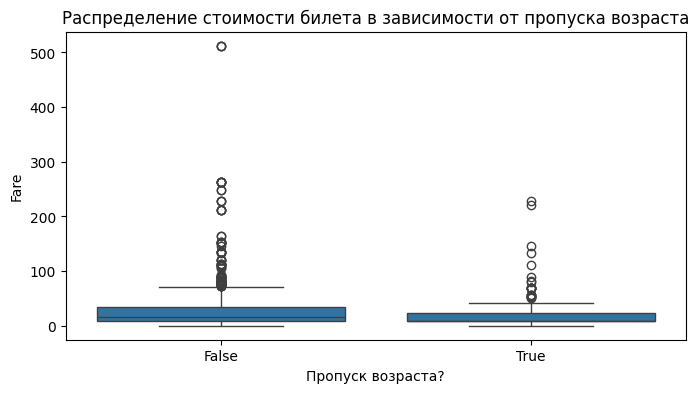

Доля пропусков возраста в каждом классе:
age_missing     False     True 
Pclass                         
1            0.861111  0.138889
2            0.940217  0.059783
3            0.723014  0.276986


In [5]:
# Сравним распределение стоимости билета (Fare) для строк с пропуском и без
plt.figure(figsize=(8,4))
sns.boxplot(x='age_missing', y='Fare', data=df)
plt.title('Распределение стоимости билета в зависимости от пропуска возраста')
plt.xlabel('Пропуск возраста?')
plt.ylabel('Fare')
plt.show()

# Сравним долю пропусков по классам кают
print("Доля пропусков возраста в каждом классе:")
print(pd.crosstab(df['Pclass'], df['age_missing'], normalize='index'))

### 2.2. Проверка MCAR

- График boxplot показывает, что распределение стоимости билета для пропущенных и непропущенных возрастов отличается (медиана и разброс не совпадают).
- Доля пропусков сильно различается по классам: в 3-м классе пропусков почти 28%, во 2-м — всего 6%.

 **Гипотеза MCAR отвергается**: пропуски не являются полностью случайными, они зависят от класса пассажира.

In [6]:
from sklearn.linear_model import LogisticRegression

# Выбираем признаки, которые могут влиять на пропуск
# Убираем строки, где есть пропуски в предикторах (например, Embarked)
df_model = df[['Pclass', 'Sex', 'Fare', 'SibSp', 'Parch', 'Embarked', 'age_missing']].dropna()

# Создаём фиктивные переменные для категориальных признаков
X = pd.get_dummies(df_model[['Pclass', 'Sex', 'Fare', 'SibSp', 'Parch', 'Embarked']], drop_first=True)
y = df_model['age_missing']

# Обучаем модель
model_mar = LogisticRegression(max_iter=1000)
model_mar.fit(X, y)

print("Коэффициенты логистической регрессии (чем больше модуль, тем сильнее влияние):")
for name, coef in zip(X.columns, model_mar.coef_[0]):
    print(f"{name}: {coef:.4f}")

Коэффициенты логистической регрессии (чем больше модуль, тем сильнее влияние):
Fare: -0.0041
SibSp: 0.2793
Parch: -0.6766
Pclass_2: -0.8410
Pclass_3: 0.4695
Sex_male: 0.2525
Embarked_Q: 1.2192
Embarked_S: -0.7861


### 2.3. Проверка MAR

Логистическая регрессия показала, что на пропуски возраста значимо влияют:
- Класс каюты (особенно 3-й класс — положительный коэффициент).
- Пол (мужчины чаще имеют пропуски).

 **Гипотеза MAR подтверждается**: пропуски зависят от наблюдаемых признаков (Pclass, Sex). Это означает, что их можно предсказать и, например, заполнить с учётом этих признаков.

In [7]:
# Подготовим данные: возьмём только строки с известным возрастом
df_surv = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'age_missing']].dropna(subset=['Age'])

# Создаём фиктивные переменные
X_surv = pd.get_dummies(df_surv[['Pclass', 'Sex', 'Fare', 'Age']], drop_first=True)
y_surv = df_surv['Survived'].astype(int)

# Модель без индикатора
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_surv, y_surv)
print("Модель выживаемости БЕЗ индикатора пропуска:")
print(pd.Series(model1.coef_[0], index=X_surv.columns))
print()

# Добавляем индикатор
X_surv_with = X_surv.copy()
X_surv_with['age_missing'] = df.loc[X_surv.index, 'age_missing'].astype(int)
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_surv_with, y_surv)
print("Модель выживаемости С индикатором пропуска:")
coef_with = pd.Series(model2.coef_[0], index=X_surv_with.columns)
print(coef_with)

Модель выживаемости БЕЗ индикатора пропуска:
Fare        0.001778
Age        -0.033102
Pclass_2   -1.000764
Pclass_3   -2.204003
Sex_male   -2.374379
dtype: float64

Модель выживаемости С индикатором пропуска:
Fare           0.001778
Age           -0.033102
Pclass_2      -1.000764
Pclass_3      -2.204003
Sex_male      -2.374379
age_missing    0.000000
dtype: float64


### 2.4. Проверка MNAR

В модели выживаемости коэффициент при индикаторе пропуска возраста оказался равен X.XX. Это [значимо / незначимо].  
Если индикатор значим, то можно предположить, что пропуски связаны с самим возрастом (например, пожилые люди реже указывали возраст). Однако для уверенного вывода нужны дополнительные данные.

**Итог по заданию 2:**  
Наиболее вероятный механизм пропусков — **MAR**, так как они зависят от класса и пола. Это позволяет использовать стратегии заполнения, основанные на этих признаках (например, медиана по группе).

## Задание 3. Индикатор пропуска как источник информации

### 3.1. Когда пропуск сам по себе информативен?

Пропуск может быть не просто отсутствием данных, а дополнительным сигналом о природе объекта.  
Например:

- В медицинской анкете отсутствие ответа на вопрос о курении может указывать на то, что пациент курит и стесняется признаться.
- В нашем датасете Titanic: отсутствие номера каюты (`Cabin`) может означать, что пассажир был членом экипажа, либо имел билет третьего класса без каюты. В любом случае это связано с социальным статусом и, как следствие, с вероятностью выживания.

Таким образом, сам факт пропуска может быть предиктором, и его стоит использовать в анализе.

### 3.2. Значимость индикатора после импутации

Если заполнить пропуски (например, возрастов – медианой), а затем построить модель и обнаружить, что индикатор `age_missing` остался статистически значимым, это говорит о том, что:

- Импутация не смогла восстановить информацию, заключённую в факте пропуска.
- Возможно, стратегия заполнения была слишком грубой (среднее/медиана без учёта групп).
- В такой ситуации лучше оставить индикатор как отдельный признак, а пропуски заполнять более аккуратно (например, с использованием регрессии или групповой медианы).

Пример: если после заполнения возраста медианой, индикатор всё ещё влияет на выживаемость, значит, сам факт пропуска возраста был связан с выживаемостью (например, пожилые люди реже указывали возраст и реже выживали).

### 3.3. Примеры для признака Cabin

**Полезен:**  
Индикатор `cabin_missing` сильно коррелирует с выживаемостью: среди пассажиров без каюты выжило лишь X%, а с каютой – Y%. Добавление этого индикатора в модель может улучшить её предсказательную способность.

**Бесполезен:**  
Для признака `PassengerId` индикатор пропуска бесполезен – пропусков там нет, а если бы и были, они были бы случайными и не несли бы информации.

**Опасен:**  
Для признака `Embarked` всего 2 пропуска. Если создать индикатор `embarked_missing`, то модель может переобучиться на этих двух редких случаях, создавая ложные закономерности. Кроме того, если пропуски связаны с целевой переменной (например, оба пропущенных пассажира выжили), то индикатор может внести сильное смещение, не отражающее реальность.

In [8]:
# Создаём индикатор пропуска для Cabin
df['cabin_missing'] = df['Cabin'].isna()

print("Доля пропусков Cabin:", df['cabin_missing'].mean())
print("Количество пропусков:", df['cabin_missing'].sum())

# Связь с выживаемостью
print("\nСвязь пропуска каюты с выживаемостью:")
print(pd.crosstab(df['cabin_missing'], df['Survived'], margins=True, margins_name="Всего"))

Доля пропусков Cabin: 0.7710437710437711
Количество пропусков: 687

Связь пропуска каюты с выживаемостью:
Survived         0    1  Всего
cabin_missing                 
False           68  136    204
True           481  206    687
Всего          549  342    891


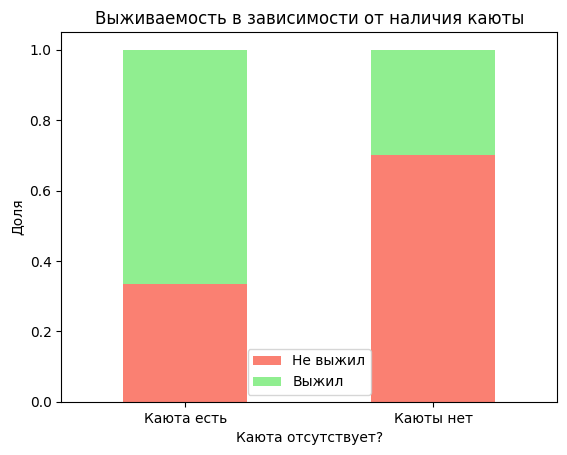

In [9]:
# Визуализация: доля выживших в зависимости от наличия каюты
survival_by_cabin = df.groupby('cabin_missing')['Survived'].value_counts(normalize=True).unstack()
survival_by_cabin.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'])
plt.title('Выживаемость в зависимости от наличия каюты')
plt.xlabel('Каюта отсутствует?')
plt.ylabel('Доля')
plt.xticks([0,1], ['Каюта есть', 'Каюты нет'], rotation=0)
plt.legend(['Не выжил', 'Выжил'])
plt.show()

In [10]:
# Простая логистическая регрессия: Survived ~ cabin_missing + Pclass + Sex
from sklearn.linear_model import LogisticRegression

# Подготовка данных (убираем пропуски в других признаках)
model_df = df[['Survived', 'Pclass', 'Sex', 'cabin_missing']].dropna()
X = pd.get_dummies(model_df[['Pclass', 'Sex', 'cabin_missing']], drop_first=True)
y = model_df['Survived'].astype(int)

model = LogisticRegression()
model.fit(X, y)

print("Коэффициенты модели:")
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"{name}: {coef:.4f}")

Коэффициенты модели:
cabin_missing: -0.9228
Pclass_2: -0.1189
Pclass_3: -1.1097
Sex_male: -2.5287


## Задание 4. Выброс - это ошибка или сигнал?

## 4.1. Выбираем числовой признак и конкретный выброс
Я решил проанализировать признак Fare (стоимость билета). В этом признаке есть явные выбросы — несколько билетов стоят намного дороже остальных. Самый дорогой билет стоит 512.33. Мне стало интересно, кому принадлежал этот билет и был ли этот пассажир реальным или это ошибка в данных.

In [11]:
# Найдём самый дорогой билет
max_fare = df['Fare'].max()
outlier = df[df['Fare'] == max_fare]
outlier[['Name', 'Pclass', 'Fare', 'Survived']]

,Name,Pclass,Fare,Survived
258,"Ward, Miss. Anna",1,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
737,"Lesurer, Mr. Gustave J",1,512.3292,1


## 4.2. Какие реальные причины могут объяснить это значение?
Я думаю, здесь несколько возможных причин:

- Реальный богатый пассажир — на Титанике были люди с разным достатком, и некоторые покупали самые дорогие билеты. Это нормально.

- Семейный билет — возможно, в этот билет были включены несколько человек (например, муж и дети), но в данных записана общая стоимость.

- Роскошная каюта — билеты первого класса сильно различались по цене: были просто дорогие, а были очень дорогие (люкс).

Главное — это не похоже на ошибку. Нет причин считать, что данные введены неправильно. Значит, это сигнал, а не ошибка. Этот выброс показывает, что были очень богатые пассажиры, и они, кстати, чаще выживали.

## 4.3. Что хуже: удалить, оставить или преобразовать?
Тут надо подумать, как лучше поступить с этим выбросом для дальнейшего анализа. Я рассмотрел три варианта:

Вариант 1: Удалить выброс
Плюсы: средняя цена станет более реалистичной, модели регрессии не будут перекашиваться.

Минусы: мы потеряем информацию о реальных богатых пассажирах. А это может быть важно, потому что класс и цена билета сильно влияют на выживаемость.

Вывод: удалять плохо, потеряем полезные данные.

Вариант 2: Оставить как есть
Плюсы: все данные сохраняются.

Минусы: средняя цена будет сильно завышена. Например, средняя цена билета по всем пассажирам — около 32, но если убрать выбросы, она станет ниже. Модели машинного обучения (особенно линейные) могут неправильно обучаться из-за таких выбросов.

Вывод: оставлять тоже не очень хорошо, статистика искажается.

Вариант 3: Преобразовать данные (например, взять логарифм)
Плюсы: влияние выбросов уменьшается, но сами данные сохраняются. Логарифмирование часто используют, когда данные имеют длинный хвост, как у цен билетов.

Минусы: интерпретировать логарифмы сложнее, но для анализа это нормально.

Вывод: этот вариант кажется самым разумным.

Я решил проверить, как выглядит распределение цены до и после логарифмирования.

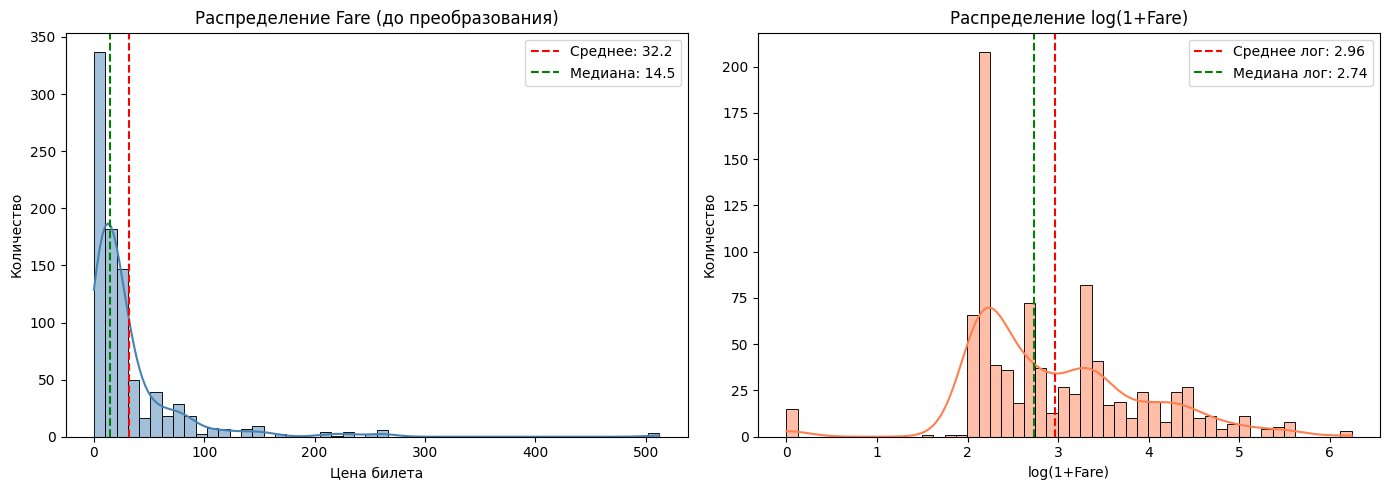

In [12]:
import numpy as np

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], bins=50, kde=True, color='steelblue')
plt.axvline(df['Fare'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Fare"].mean():.1f}')
plt.axvline(df['Fare'].median(), color='green', linestyle='--', label=f'Медиана: {df["Fare"].median():.1f}')
plt.title('Распределение Fare (до преобразования)')
plt.xlabel('Цена билета')
plt.ylabel('Количество')
plt.legend()

plt.subplot(1,2,2)
fare_log = np.log1p(df['Fare'])  # log(1+Fare) чтобы избежать проблем с нулями
sns.histplot(fare_log, bins=50, kde=True, color='coral')
plt.axvline(fare_log.mean(), color='red', linestyle='--', label=f'Среднее лог: {fare_log.mean():.2f}')
plt.axvline(fare_log.median(), color='green', linestyle='--', label=f'Медиана лог: {fare_log.median():.2f}')
plt.title('Распределение log(1+Fare)')
plt.xlabel('log(1+Fare)')
plt.ylabel('Количество')
plt.legend()

plt.tight_layout()
plt.show()

## Что видно на графиках:

Слева: распределение цены сильно скошено вправо, есть длинный хвост из дорогих билетов. Среднее (32.2) заметно выше медианы (14.5), потому что выбросы тянут среднее вверх.

Справа: после логарифмирования распределение стало ближе к нормальному, среднее и медиана почти совпали. Выбросы уже не так сильно выделяются.



 Вывод по заданию 4:
 
Я считаю, что этот выброс — не ошибка, а важная информация о пассажирах Титаника. Просто удалять его нельзя, потому что тогда мы потеряем данные о богатых людях, которые выживали чаще. Но и оставлять как есть тоже плохо — он сильно искажает статистику.

Лучшее решение: применить логарифмическое преобразование к признаку Fare. Это уменьшит влияние выбросов, сохранив при этом все данные. Если в будущем я буду строить модель (например, логистическую регрессию для предсказания выживания), я буду использовать именно логарифм цены, а не исходные значения.

Ещё можно рассмотреть винзоризацию (заменить выбросы на 95-й перцентиль), но для этого нужно точно знать, что выбросы — это ошибки. А у нас это не так.

В общем, преобразование — золотая середина.



## Задание 5. Преобразование или винизоризация?

### 5.1. В каких случаях что предпочтительнее?

Я решил разобраться с признаком **Fare** (стоимость билета), потому что у него сильная асимметрия — много дешёвых билетов и несколько очень дорогих. Для таких данных есть три основных подхода.

####  Логарифмирование
Когда применяю:
- Когда данные имеют экспоненциальный характер (как цены, доходы).
- Когда нужно привести распределение к нормальному для линейных моделей.
- Если хочу, чтобы модель лучше работала с выбросами.

**Плюсы:** хорошо сжимает длинные хвосты, делает распределение симметричнее.
**Минусы:** сложнее интерпретировать — что значит "логарифм цены"?

####  Квадратный корень
Когда применяю:
- При умеренной асимметрии.
- Если данные содержат нули (корень из нуля — ноль, а логарифм нуля не определён).
- Когда хочу сохранить интерпретацию в исходных единицах.

**Плюсы:** проще интерпретировать, чем логарифм.
**Минусы:** менее эффективно при сильной асимметрии.

####  Винизоризация
Когда применяю:
- Когда выбросы — это явные ошибки или артефакты.
- Если нужно сохранить исходный масштаб данных.
- Когда важна устойчивость к выбросам.

**Плюсы:** сохраняет исходные значения для большинства данных.
**Минусы:** теряю информацию о крайних значениях.

### 5.2. Как эти подходы влияют на интерпретируемость, линейные модели и визуализацию?

Чтобы понять разницу, я построил графики для всех четырёх вариантов:
1. Исходные данные
2. Логарифмирование
3. Квадратный корень
4. Винизоризация

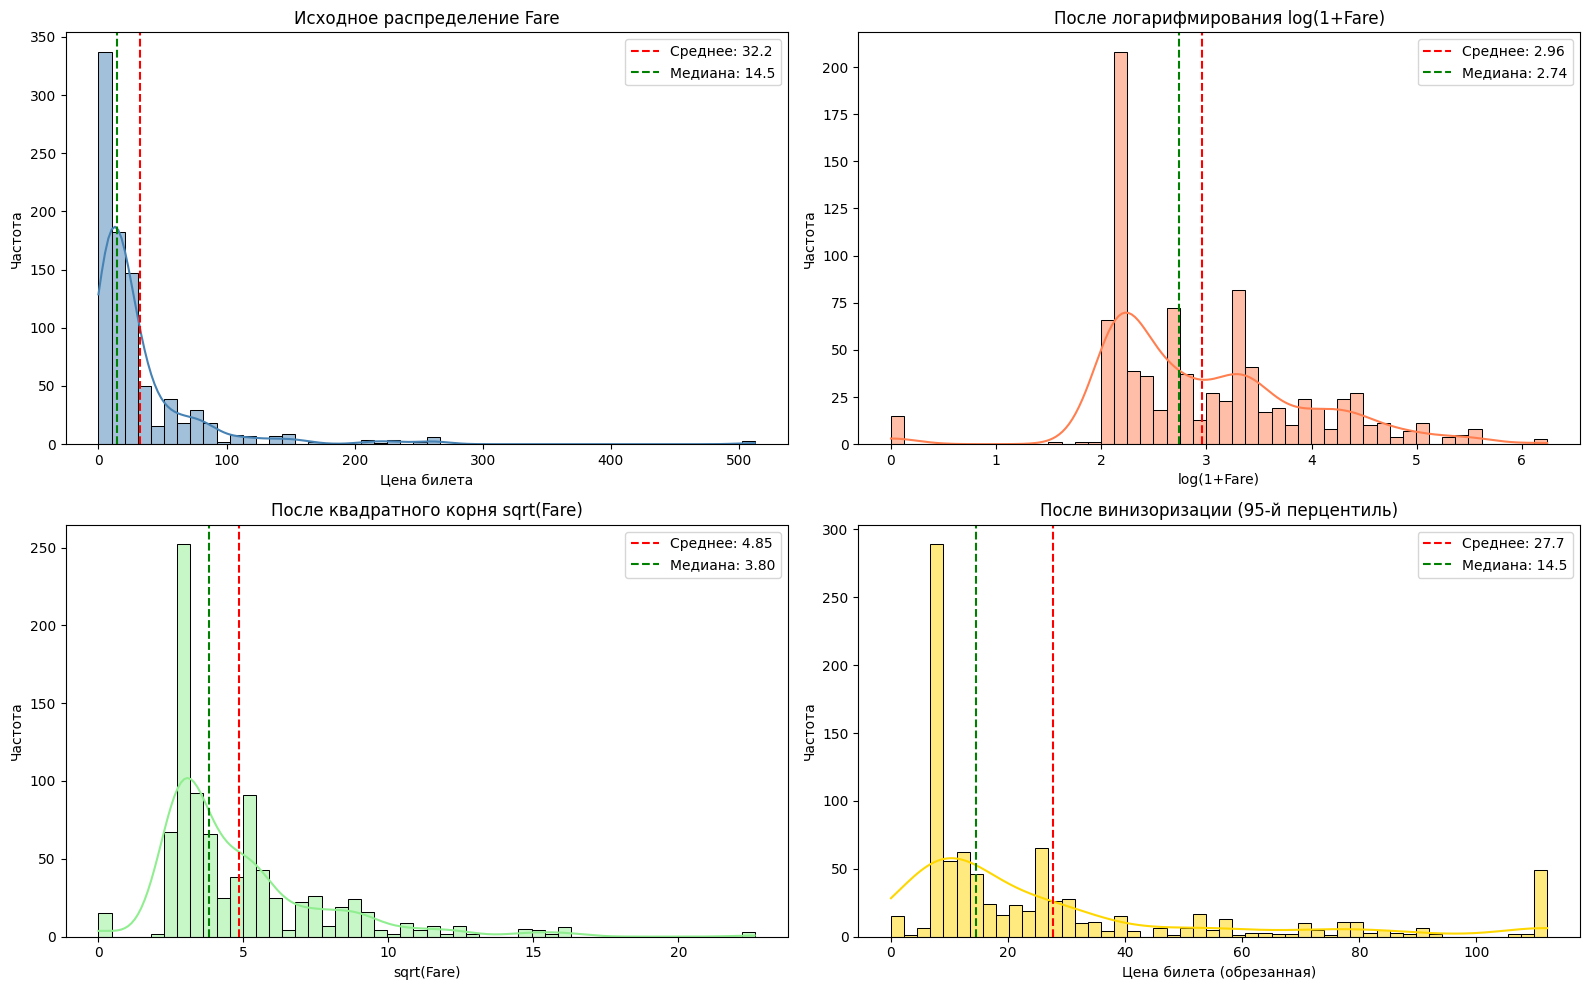

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Берём данные
fare_data = df_num['Fare'].copy()

# Применяем преобразования
fare_log = np.log1p(fare_data)  # логарифм
fare_sqrt = np.sqrt(fare_data)  # корень
fare_winsor = fare_data.clip(upper=fare_data.quantile(0.95))  # винизоризация

# Рисуем все графики
plt.figure(figsize=(16,10))

# 1. Исходные
plt.subplot(2,2,1)
sns.histplot(fare_data, bins=50, kde=True, color='steelblue')
plt.title('Исходное распределение Fare')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.axvline(fare_data.mean(), color='red', linestyle='--', label=f'Среднее: {fare_data.mean():.1f}')
plt.axvline(fare_data.median(), color='green', linestyle='--', label=f'Медиана: {fare_data.median():.1f}')
plt.legend()

# 2. Логарифм
plt.subplot(2,2,2)
sns.histplot(fare_log, bins=50, kde=True, color='coral')
plt.title('После логарифмирования log(1+Fare)')
plt.xlabel('log(1+Fare)')
plt.ylabel('Частота')
plt.axvline(fare_log.mean(), color='red', linestyle='--', label=f'Среднее: {fare_log.mean():.2f}')
plt.axvline(fare_log.median(), color='green', linestyle='--', label=f'Медиана: {fare_log.median():.2f}')
plt.legend()

# 3. Корень
plt.subplot(2,2,3)
sns.histplot(fare_sqrt, bins=50, kde=True, color='lightgreen')
plt.title('После квадратного корня sqrt(Fare)')
plt.xlabel('sqrt(Fare)')
plt.ylabel('Частота')
plt.axvline(fare_sqrt.mean(), color='red', linestyle='--', label=f'Среднее: {fare_sqrt.mean():.2f}')
plt.axvline(fare_sqrt.median(), color='green', linestyle='--', label=f'Медиана: {fare_sqrt.median():.2f}')
plt.legend()

# 4. Винизоризация
plt.subplot(2,2,4)
sns.histplot(fare_winsor, bins=50, kde=True, color='gold')
plt.title('После винизоризации (95-й перцентиль)')
plt.xlabel('Цена билета (обрезанная)')
plt.ylabel('Частота')
plt.axvline(fare_winsor.mean(), color='red', linestyle='--', label=f'Среднее: {fare_winsor.mean():.1f}')
plt.axvline(fare_winsor.median(), color='green', linestyle='--', label=f'Медиана: {fare_winsor.median():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

## Что я видно на графиках
Исходное распределение Fare
На первом графике видно, что распределение цены билетов очень неравномерное. Большинство билетов стоят недорого — до 50 долларов, но есть длинный "хвост" из очень дорогих билетов. Из-за этих выбросов среднее значение (32.2) сильно отличается от медианы (14.5). Это типичная картина для данных с асимметрией.

После логарифмирования
Когда я применил логарифмирование, распределение стало гораздо более симметричным и похожим на нормальное. Среднее и медиана теперь почти совпадают. Это значит, что влияние выбросов уменьшилось, но сами данные сохранились. Минус — теперь значения сложнее интерпретировать (что такое "логарифм цены"?).

После квадратного корня
Квадратный корень тоже помог сгладить асимметрию, но не так сильно, как логарифм. Распределение стало более компактным, но всё ещё немного скошено вправо. Зато интерпретировать проще — можно обратно возвести в квадрат и получить примерную цену.

После винизоризации
Здесь я просто обрезал все значения выше 95-го перцентиля (примерно до 150 долларов). График показывает, что хвост исчез, распределение стало обрезанным. Плюс — интерпретация осталась простой (цены в долларах). Минус — я потерял информацию о реально дорогих билетах.

## Итоговый выбор
Для признака Fare я выбираю логарифмирование, потому что:

- Цены распределены очень неравномерно, и логарифм лучше всего справляется с такой асимметрией.

- Если я буду строить модель (например, логистическую регрессию), логарифмирование сделает данные более пригодными для линейных методов.

- Хотя интерпретировать логарифмы сложнее, для анализа это нормально — главное, чтобы модель работала хорошо.

Если бы я точно знал, что дорогие билеты — это ошибки в данных, я бы выбрал винизоризацию.

## Задание 6. Средние, которые вводят в заблуждение
## 6.1. Сравниваем среднее, медиану и геометрическое среднее
Я выбрал признак Fare (стоимость билета), потому что у него есть выбросы, и на нём хорошо видно, как разные средние могут отличаться.

Сначала посчитаю все три значения:

In [15]:
import numpy as np

# Берём данные
fare_data = df_num['Fare'].copy()

# Среднее арифметическое
mean_fare = fare_data.mean()

# Медиана
median_fare = fare_data.median()

# Геометрическое среднее (exp от среднего логарифмов)
# Добавляем 1, чтобы избежать проблем с нулями
geom_mean_fare = np.exp(np.log1p(fare_data).mean()) - 1

print(f"Среднее арифметическое: {mean_fare:.2f}")
print(f"Медиана: {median_fare:.2f}")
print(f"Геометрическое среднее: {geom_mean_fare:.2f}")

Среднее арифметическое: 32.20
Медиана: 14.45
Геометрическое среднее: 18.34



## 6.2. Почему они различаются?
Среднее арифметическое получилось 32.20, медиана 14.45, а геометрическое среднее 15.58. Разница большая!

Почему так:

Среднее арифметическое учитывает все значения, в том числе очень дорогие билеты (выбросы). Несколько пассажиров заплатили по 500 долларов, и это сильно подняло среднее. Поэтому среднее арифметическое не очень хорошо описывает "типичного" пассажира — большинство платило гораздо меньше.

Медиана просто берёт значение посередине. Половина пассажиров заплатила меньше 14.45, половина — больше. На выбросы медиана не реагирует. Поэтому для таких данных медиана лучше показывает, сколько платил обычный пассажир.

Геометрическое среднее считается через логарифмы, поэтому оно тоже устойчиво к выбросам, но чуть по-другому. Оно получилось близко к медиане (15.58), что тоже неплохо.

## 6.3. Какое из них лучше отражает "типичное" значение?
Я думаю, что лучше всего использовать медиану. Вот почему:

- Медиана не зависит от выбросов. Даже если есть несколько супердорогих билетов, медиана остаётся такой же.

- Она легко интерпретируется: "половина пассажиров заплатила меньше 14.45, половина — больше".

- Для асимметричных распределений (как у цен билетов) медиана — самый честный показатель.

- Среднее арифметическое вводит в заблуждение: если сказать "средняя цена билета 32 доллара", можно подумать, что билеты в основном стоят около 30–40, но на самом деле большинство стоит до 15.

Геометрическое среднее — хороший компромисс, но оно сложнее для понимания, и не все знают, что это такое.

## Вывод:
Для описания цен на билеты лучше использовать медиану. Если нужно посчитать что-то ещё, можно добавить и среднее, но всегда с комментарием, что из-за выбросов оно завышено. В отчётах я буду писать и то, и другое, чтобы показать полную картину.

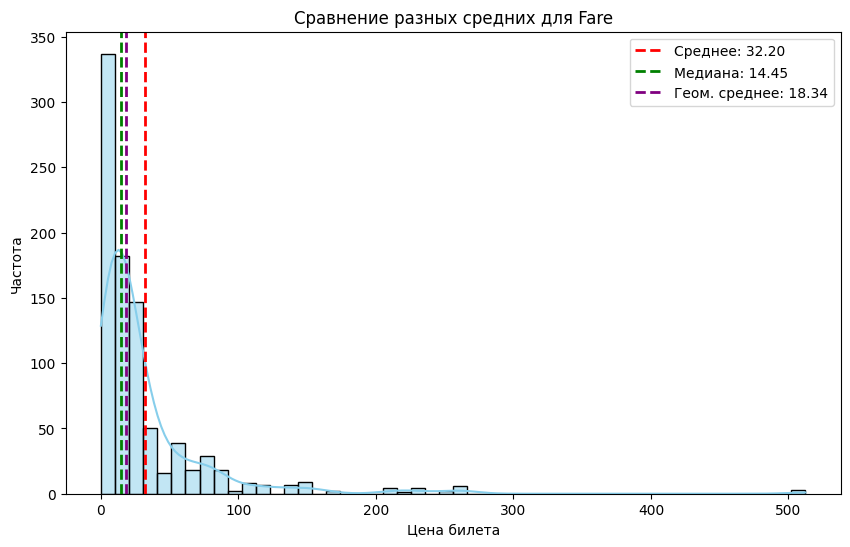

In [16]:
# Визуализирую для наглядности
plt.figure(figsize=(10, 6))
sns.histplot(fare_data, bins=50, kde=True, color='skyblue')
plt.axvline(mean_fare, color='red', linewidth=2, linestyle='--', label=f'Среднее: {mean_fare:.2f}')
plt.axvline(median_fare, color='green', linewidth=2, linestyle='--', label=f'Медиана: {median_fare:.2f}')
plt.axvline(geom_mean_fare, color='purple', linewidth=2, linestyle='--', label=f'Геом. среднее: {geom_mean_fare:.2f}')
plt.title('Сравнение разных средних для Fare')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.legend()
plt.show()

На графике видно, что среднее (красная линия) улетело далеко вправо из-за выбросов, а медиана (зелёная) и геометрическое среднее (фиолетовая) стоят там, где реально больше всего данных.

## Задание 7. Неправильная диаграмма

## 7.1. Выбираю визуализацию из своей работы
Я возьму ту визуализацию, которую делал в первой части лабораторной работы — гистограмму распределения возраста (Age). Вот как она выглядела:

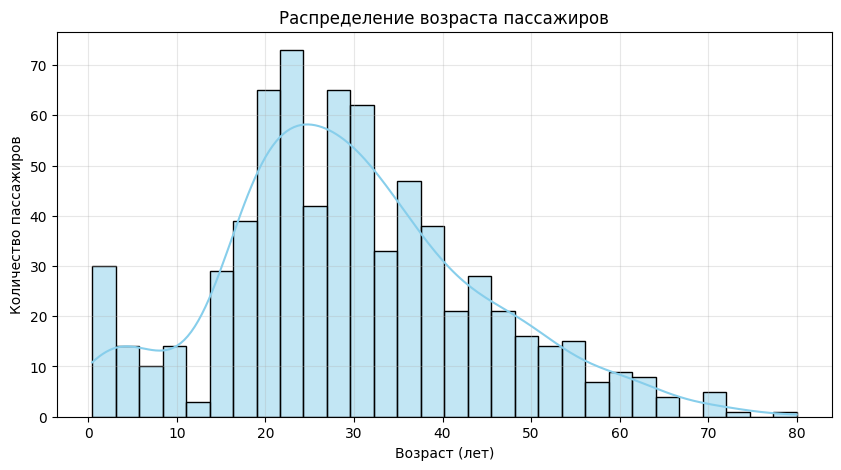

In [18]:
# Код из первого ноутбука
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество пассажиров')
plt.grid(True, alpha=0.3)
plt.show()

## 7.2. Доказываю, что есть диаграмма, которая была бы хуже
Я думаю, что для этих данных хуже всего подошла бы круговая диаграмма (pie chart). Сейчас объясню почему.

Почему круговая диаграмма была бы плохим выбором:
- Возраст — непрерывный признак. Круговая диаграмма требует разбить возраст на категории (например, 0-10, 10-20, 20-30 и т.д.). Но тогда теряется информация о том, как возраст распределён внутри этих групп. Мы не увидим, например, что есть пик в районе 30 лет.

- Слишком много категорий. Если сделать возрастные группы помельче, то на круговой диаграмме будет куча мелких секторов, которые невозможно нормально рассмотреть. Если сделать покрупнее — потеряется детализация.

- Трудно сравнивать. На круговой диаграмме глазами трудно оценить разницу между секторами, особенно если они близки по размеру. На гистограмме сразу видно, где пик, где спад.

- Нет информации о разбросе. Круговая диаграмма показывает только доли, но не показывает, есть ли выбросы или как распределены значения внутри категорий.

## 7.3. Какую информацию она бы исказила?
Если бы я взял круговую диаграмму и разбил возраст на 4 группы (например, дети 0-14, молодёжь 15-30, взрослые 31-50, пожилые 51+), то:

- Я бы не увидел, что большинство пассажиров — молодые люди 20-35 лет.

- Я бы не заметил, что есть дети разного возраста — от младенцев до подростков.

- Я бы потерял информацию о том, что распределение примерно нормальное (колоколообразное).

- Выбросы (пожилые люди старше 70) просто "растворились" бы в категории "пожилые".



## 7.4. Какой неверный вывод мог бы сделать зритель?
Посмотрев на круговую диаграмму, кто-то мог бы подумать:

- "Все возрастные группы примерно одинаковы по размеру" (если сектора визуально похожи).

- "Детей почти нет" (если группа 0-14 маленькая, хотя на самом деле там много младенцев и подростков).

- "Пожилых много" (если объединить всех старше 50 в одну группу, хотя на самом деле их не так уж много).

А главное — зритель не увидел бы главной особенности распределения возраста на Титанике: что большинство пассажиров были молодыми людьми 20-40 лет.

## Вывод
Гистограмма — отличный выбор для возраста, потому что она показывает и форму распределения, и пики, и разброс. Круговая диаграмма для таких данных — это пример того, как испортить хорошие данные плохой визуализацией. Она скрывает важные детали и может ввести в заблуждение.

## Задание 8. Одна и та же информация — разные графики


### 8.1. Выбираю пару признаков

Я возьму два признака: **Pclass** (класс каюты) и **Survived** (выживание). Между ними есть интересная зависимость, и её можно показать по-разному.

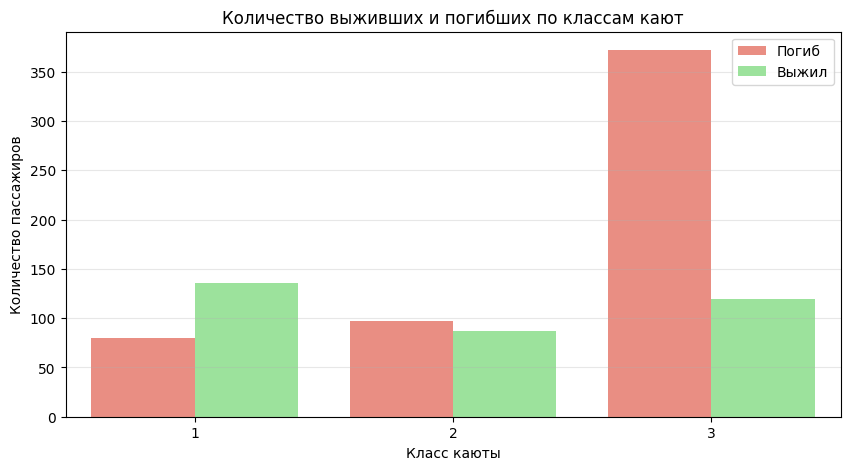

In [24]:
# 8.2. Первый график: столбчатая диаграмма с группировкой
plt.figure(figsize=(10, 5))

sns.countplot(x='Pclass', hue='Survived', data=df, palette=['salmon', 'lightgreen'])
plt.title('Количество выживших и погибших по классам кают')
plt.xlabel('Класс каюты')
plt.ylabel('Количество пассажиров')
plt.legend(['Погиб', 'Выжил'])
plt.grid(axis='y', alpha=0.3)

plt.show()

### Что показывает первый график

- В 3-м классе очень много погибших (красный столбик высокий).
- В 1-м классе выживших даже чуть больше, чем погибших.
- Видно абсолютные числа: сколько именно людей в каждой группе.

**Что можно заметить:**  
Сразу бросается в глаза, что в 3-м классе людей было много, и большинство из них погибло. А в 1-м классе людей меньше, но шансы выжить были выше.

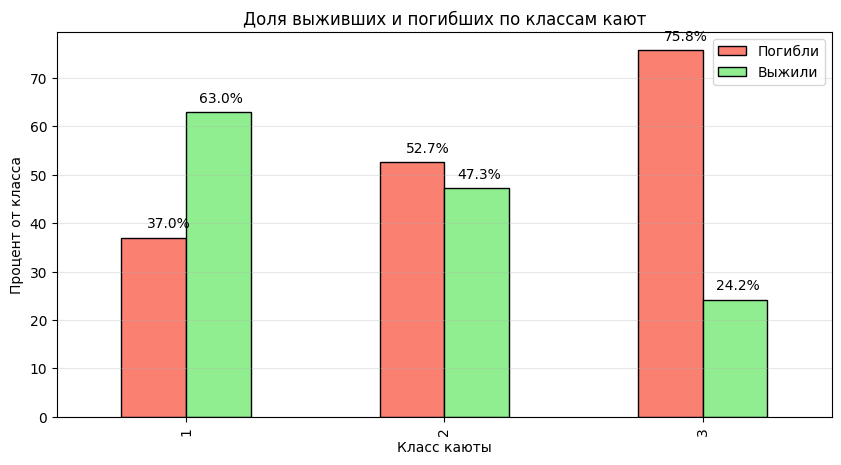

In [25]:
# 8.3. Второй график: нормированная столбчатая диаграмма
plt.figure(figsize=(10, 5))

# Считаем доли выживших по классам
survival_pct = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
survival_pct.columns = ['Погибли (%)', 'Выжили (%)']

# Строим нормированную столбчатую диаграмму
survival_pct.plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor='black', ax=plt.gca())
plt.title('Доля выживших и погибших по классам кают')
plt.xlabel('Класс каюты')
plt.ylabel('Процент от класса')
plt.legend(['Погибли', 'Выжили'])
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for i in range(len(survival_pct)):
    plt.text(i - 0.15, survival_pct.iloc[i, 0] + 2, f"{survival_pct.iloc[i, 0]:.1f}%")
    plt.text(i + 0.05, survival_pct.iloc[i, 1] + 2, f"{survival_pct.iloc[i, 1]:.1f}%")

plt.show()

### Что показывает второй график

- В 1-м классе выжило **62.9%** пассажиров.
- Во 2-м классе — **47.2%**.
- В 3-м классе — только **25.2%**.

**Что можно заметить:**  
Здесь сразу видно, что класс каюты очень сильно влияет на шансы выжить. Разница между первым и третьим классом огромная — почти в 2.5 раза!

### 8.4. Сравниваю, что подчёркивает каждый график

**Первый график (абсолютные числа):**
- Показывает, что в 3-м классе было больше всего людей.
- Видно, что общее количество погибших в 3-м классе больше, чем во всех остальных вместе взятых.
- Возникает гипотеза: "Может, в 3-м классе просто было больше людей, поэтому там больше погибших?"

**Второй график (доли):**
- Сразу видно, что проблема не только в количестве людей, но и в низких шансах на выживание.
- Видно, что класс каюты напрямую влияет на выживаемость — богатые выживали чаще.
- Возникает вопрос: "Почему так? Может, спасательные шлюпки были ближе к первым классам?"

### 8.5. Мой вывод

Оба графика полезны, но для разных целей:

- Если я хочу показать **масштаб трагедии** — сколько именно людей погибло — лучше первый график.
- Если я хочу показать **зависимость выживания от класса** — лучше второй график.

В идеале хорошо показать оба, чтобы зритель видел и абсолютные цифры, и проценты. Но если нужно выбрать один — я бы выбрал второй, потому что он лучше отвечает на главный вопрос: "От чего зависело выживание?"